# Analisis Univariado



A continuación se procederá a examinar cada variable de forma individual con el objetivo de entender su distribución, medidas centrales y de dispersión. Para complementar el análisis utilizaremos tablas estadísticas y gráficas según se considere adecuado

## 1. Introducción

La diabetes es una enfermedad crónica que afecta a millones de personas en el mundo y constituye uno de los principales problemas de salud pública debido a sus complicaciones cardiovasculares, renales y neurológicas. Identificar los factores asociados a su aparición es fundamental para diseñar estrategias de prevención y detección temprana.

Este notebook desarrolla el **análisis exploratorio univariado** del conjunto de datos `diabetes_binary_5050split_health_indicators_BRFSS2015`, derivado de la encuesta *Behavioral Risk Factor Surveillance System* (BRFSS) del año 2015. El conjunto está balanceado 50/50 entre personas con y sin diabetes/prediabetes, e incluye variables demográficas, de estilo de vida y de condición de salud.

El análisis univariado permite conocer, variable por variable, su distribución, frecuencia y principales medidas de tendencia central y dispersión, sentando las bases para el posterior análisis bivariado frente a la variable de respuesta `Diabetes`.

## 2. Objetivos

**Objetivo general**

Describir de forma individual el comportamiento de las variables del conjunto de datos `diabetes_binary_5050split_health_indicators_BRFSS2015`, mediante tablas de frecuencia, medidas estadísticas y representaciones gráficas.

**Objetivos específicos**

- Calcular tablas de frecuencia y porcentaje para cada variable categórica del conjunto de datos.
- Construir representaciones gráficas de barras que permitan visualizar la distribución de cada variable categórica.
- Calcular medidas de tendencia central y dispersión (media, mínimo, máximo, rango intercuartílico) para las variables numéricas.
- Identificar posibles asimetrías, valores atípicos o desbalances relevantes en las variables analizadas.
- Establecer una base descriptiva que sirva de insumo para el análisis bivariado posterior frente a la variable `Diabetes`.

## 3. Marco Teórico

**Diabetes y prediabetes**: la diabetes es un trastorno metabólico caracterizado por niveles elevados de glucosa en sangre, asociado a factores como la obesidad, el sedentarismo, la hipertensión y el colesterol alto. La prediabetes corresponde a un estado intermedio de riesgo previo al desarrollo de la enfermedad.

**Análisis exploratorio de datos (EDA)**: conjunto de técnicas estadísticas y gráficas utilizadas para resumir las principales características de un conjunto de datos antes de aplicar modelos más complejos. Incluye la construcción de tablas de frecuencia, medidas de resumen y visualizaciones.

**Variables categóricas y numéricas**: las variables categóricas (binarias u ordinales) se resumen mediante tablas de frecuencia y gráficos de barras, mientras que las variables numéricas se describen mediante medidas de tendencia central (media, mediana) y de dispersión (rango intercuartílico, mínimo y máximo), complementadas con histogramas.

**Medidas de dispersión**: el rango intercuartílico (IQR = Q3 - Q1) mide la dispersión del 50% central de los datos y es especialmente útil en variables con distribuciones asimétricas o con muchos valores repetidos, como ocurre con varias variables de este conjunto de datos.

## 4. Metodología

Para cada variable del conjunto de datos se siguió el mismo procedimiento:

1. **Variables categóricas** (binarias u ordinales): se construyó una tabla de frecuencias absolutas y porcentuales, y se representó su distribución mediante un **gráfico de barras**, utilizando una paleta de colores unificada en todo el notebook (azul para la categoría 0 / "No" y naranja para la categoría 1 / "Sí" en variables binarias; un único color en variables con más de dos categorías ordinales).
2. **Variables numéricas** (`IMC`, `SaludM`, `SaludF`): se calcularon medidas de tendencia central y dispersión (media, mínimo, máximo, rango intercuartílico) y se representó su distribución mediante **gráficos de barras** (histograma de frecuencias para `IMC`, y conteo de frecuencias por número de días para `SaludM` y `SaludF`).

Todas las gráficas comparten la misma paleta de colores para facilitar la comparación visual entre variables.

## Librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")


COLOR_NO = "#06347D"     # azul: categoría 0 / "No"
COLOR_SI = "#E80808"     # naranja: categoría 1 / "Sí"
COLOR_UNICO = "#E6E909"  
PALETA_BINARIA = [COLOR_NO, COLOR_SI]


def formatear_miles(ax, eje='y'):
    formatter = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
    if eje == 'y':
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def graficar_barras_binarias(tabla, columna, titulo, etiquetas, xlabel, ylabel,
                              order=(0.0, 1.0), figsize=(8, 6)):
    """Gráfico de barras verticales para una variable binaria (0/1),
    con la paleta de colores unificada (azul = 0, naranja = 1)."""
    plt.figure(figsize=figsize)

    ax = sns.barplot(data=tabla, x=columna, y='Frecuencia',
                    order=list(order), palette=PALETA_BINARIA)
    formatear_miles(ax, 'y')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(etiquetas, fontsize=11)

    for p, cat in zip(ax.patches, order):
        pct = tabla.loc[tabla[columna] == cat, 'Porcentaje'].values[0]
        ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, color='black',
                    xytext=(0, 5), textcoords='offset points')

    plt.ylim(0, tabla['Frecuencia'].max() * 1.18)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    plt.show()


def graficar_barras_categoricas(tabla, columna, titulo, xlabel, ylabel,
                                 etiquetas=None, figsize=(10, 6), rotation=0):
    """Gráfico de barras para una variable con más de dos categorías,
    utilizando un único color (evita el efecto 'carnaval' de colores)."""
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=tabla, x=columna, y='Frecuencia', color=COLOR_UNICO)
    formatear_miles(ax, 'y')
    if etiquetas is not None:
        ax.set_xticks(range(len(etiquetas)))
        ax.set_xticklabels(etiquetas, rotation=rotation, fontsize=10)

    for i, p in enumerate(ax.patches):
        pct = tabla['Porcentaje'].iloc[i]
        ax.annotate(f"{int(p.get_height()):,}\n({pct}%)",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black',
                    xytext=(0, 5), textcoords='offset points')

    plt.ylim(0, tabla['Frecuencia'].max() * 1.18)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()
    plt.show()

## 5. Carga y Preparación de Datos

In [9]:
filename=r"Data\diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

df = pd.read_csv(filename, sep=',')

df = df.rename(columns={
    'Diabetes_binary': 'Diabetes',
    'HighBP':         'PA_alta',
    'HighChol':     'col_alto',
    'CholCheck':   'CheckCol',
    'BMI':  'IMC',
    'Smoker':   'Fumador',
    'Stroke':      'derrame',
    'HeartDiseaseorAttack': 'EnfCardi',
    'PhysActivity':  'ActFisi',
    'Fruits':    'fruta',
    'Veggies':   'vegetales',
    'HvyAlcoholConsump':     'Alcohlico',
    'AnyHealthcare':        'eps',
    'NoDocbcCost':    'AfordabilidadMedica',
    'GenHlth':         'SaludG',
    'MentHlth':        'SaludM',
    'PhysHlth':        'SaludF',
    'DiffWalk':        'DificultadCaminar',
    'Sex': 'Genero',
    'Age': 'Edad',
    'Education': 'Educacion',
    'Income': 'Ingresos'
})[[  
    'Diabetes', 'PA_alta', 'col_alto', 'CheckCol', 
    'IMC', 'Fumador', 'derrame', 'EnfCardi', 'ActFisi', 
    'fruta', 'vegetales', 'Alcohlico', 'eps', 'AfordabilidadMedica', 
    'SaludG', 'SaludM', 'SaludF', 'DificultadCaminar', 'Genero',
    'Edad', 'Educacion', 'Ingresos'
]]


df = df.drop_duplicates()
df.head()

,Diabetes,PA_alta,col_alto,CheckCol,IMC,Fumador,derrame,EnfCardi,ActFisi,fruta,...,eps,AfordabilidadMedica,SaludG,SaludM,SaludF,DificultadCaminar,Genero,Edad,Educacion,Ingresos
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 6. Variables Categóricas

### Variable Respuesta: (`Diabetes`)

**Tabla**

In [10]:
tabla_y = (
    df['Diabetes']
    .value_counts()
    .reset_index()
    .rename(columns={'Diabetes': 'Diabetes', 'count': 'Frecuencia'})
)

tabla_y['Porcentaje'] = (tabla_y['Frecuencia'] / tabla_y['Frecuencia'].sum() * 100).round(1)

tabla_y

,Diabetes,Frecuencia,Porcentaje
0,1.0,35097,50.8
1,0.0,33960,49.2


Como podemos observar, dado que el archivo es el conjunto de datos con la división 50/50 (5050split), la clase está perfectamente balanceada con exactamente la misma cantidad de registros para pacientes con y sin diabetes.

**Grafico** 

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


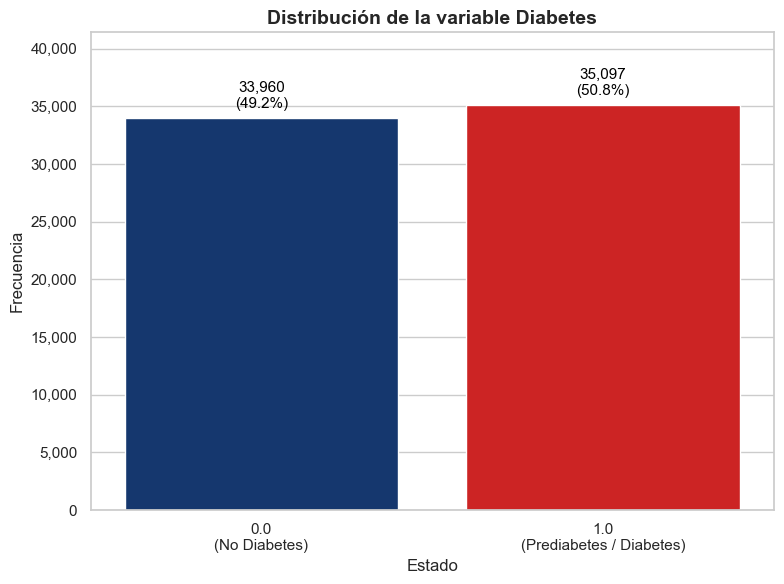

In [11]:
graficar_barras_binarias(
    tabla_y, 'Diabetes',
    titulo='Distribución de la variable Diabetes',
    etiquetas=['0.0\n(No Diabetes)', '1.0\n(Prediabetes / Diabetes)'],
    xlabel='Estado', ylabel='Frecuencia'
)

Este gráfico muestra la distribución de los pacientes con y sin diabetes, confirmando que tiene distribucion igual.

 (`PA_alta`): Corresponde a la variable que nos dice si el paciente cuenta con presion arterial alta o no.

**Tabla** 

In [12]:

tabla_pa = (
    df['PA_alta']
    .value_counts()
    .reset_index()
    .rename(columns={'PA_alta': 'PA_alta', 'count': 'Frecuencia'})
)


tabla_pa['Porcentaje'] = (tabla_pa['Frecuencia'] / tabla_pa['Frecuencia'].sum() * 100).round(1)


tabla_pa

,PA_alta,Frecuencia,Porcentaje
0,1.0,39447,57.1
1,0.0,29610,42.9


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


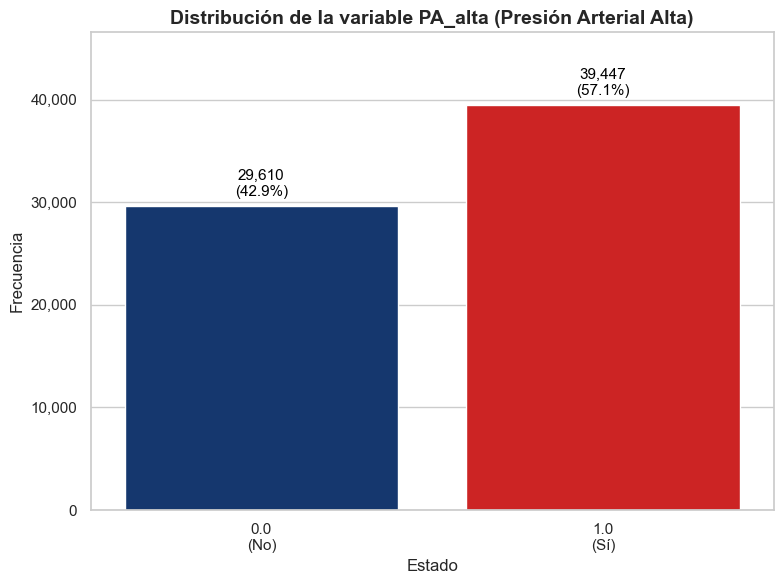

In [13]:
graficar_barras_binarias(
    tabla_pa, 'PA_alta',
    titulo='Distribución de la variable PA_alta (Presión Arterial Alta)',
    etiquetas=['0.0\n(No)', '1.0\n(Sí)'],
    xlabel='Estado', ylabel='Frecuencia'
)

Como podemos observar en la tabla, el 56.3% de los participantes en esta base de datos balanceada reportan haber sido diagnosticados con presión arterial alta, mientras que el 43.7% no tienen esta condición.

(`col_alto`): Esta variable corresponde a si el paciente cuenta con un colesterol alto o no.

**Tabla**

In [14]:
tabla_col = (
    df['col_alto']
    .value_counts()
    .reset_index()
    .rename(columns={'col_alto': 'col_alto', 'count': 'Frecuencia'})
)
tabla_col['Porcentaje'] = (tabla_col['Frecuencia'] / tabla_col['Frecuencia'].sum() * 100).round(1)


print(tabla_col)

   col_alto  Frecuencia  Porcentaje
0       1.0       36692        53.1
1       0.0       32365        46.9


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


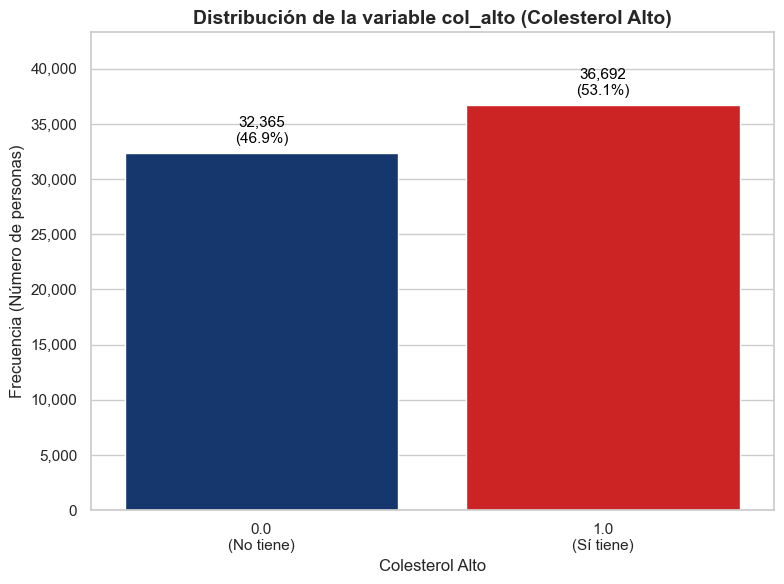

In [15]:
graficar_barras_binarias(
    tabla_col, 'col_alto',
    titulo='Distribución de la variable col_alto (Colesterol Alto)',
    etiquetas=['0.0\n(No tiene)', '1.0\n(Sí tiene)'],
    xlabel='Colesterol Alto', ylabel='Frecuencia (Número de personas)'
)

La tabla indica que hay una proporción ligeramente mayor de personas diagnosticadas con colesterol alto (52.6%) en comparación con aquellas que no lo padecen (47.4%).

(`CheckCol`): Esta variable nos dice si el paciente se realizo examenes que chequeen su colesterol en los ultimos 5 años. 

**Tabla**

In [16]:
tabla_checkcol = (
    df['CheckCol']
    .value_counts()
    .reset_index()
    .rename(columns={'CheckCol': 'CheckCol', 'count': 'Frecuencia'})
)
tabla_checkcol['Porcentaje'] = (tabla_checkcol['Frecuencia'] / tabla_checkcol['Frecuencia'].sum() * 100).round(1)
print(tabla_checkcol)

   CheckCol  Frecuencia  Porcentaje
0       1.0       67317        97.5
1       0.0        1740         2.5


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


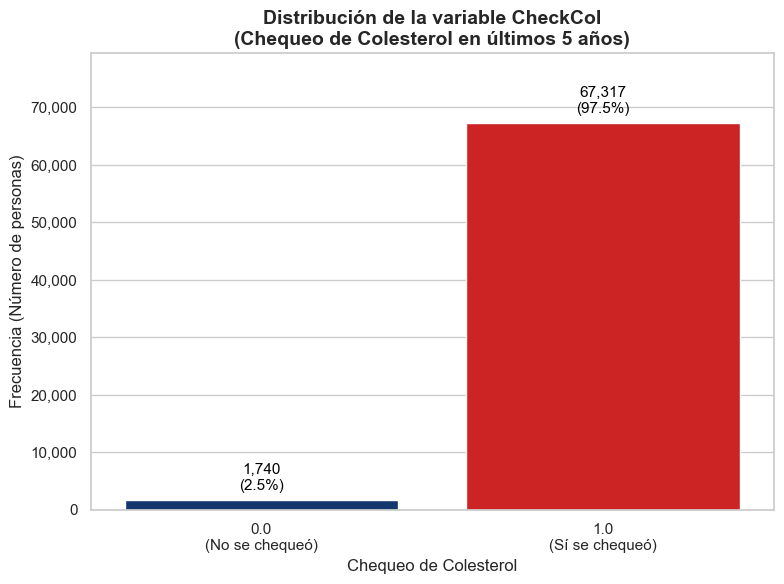

In [17]:
graficar_barras_binarias(
    tabla_checkcol, 'CheckCol',
    titulo='Distribución de la variable CheckCol\n(Chequeo de Colesterol en últimos 5 años)',
    etiquetas=['0.0\n(No se chequeó)', '1.0\n(Sí se chequeó)'],
    xlabel='Chequeo de Colesterol', ylabel='Frecuencia (Número de personas)'
)

Como podemos observar, la inmensa mayoría de las personas en esta base de datos (97.5%) sí se han realizado un chequeo de colesterol recientemente, mientras que solamente el 2.5% no se ha chequeado en los ultimos 5 años. 


(`Fumador`): Nos dice si el paciente fuma o no. 

**Tabla**

In [18]:
tabla_fumador = (
    df['Fumador']
    .value_counts()
    .reset_index()
    .rename(columns={'Fumador': 'Fumador', 'count': 'Frecuencia'})
)
tabla_fumador['Porcentaje'] = (tabla_fumador['Frecuencia'] / tabla_fumador['Frecuencia'].sum() * 100).round(1)


print(tabla_fumador)

   Fumador  Frecuencia  Porcentaje
0      0.0       35776        51.8
1      1.0       33281        48.2


**Grafica**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


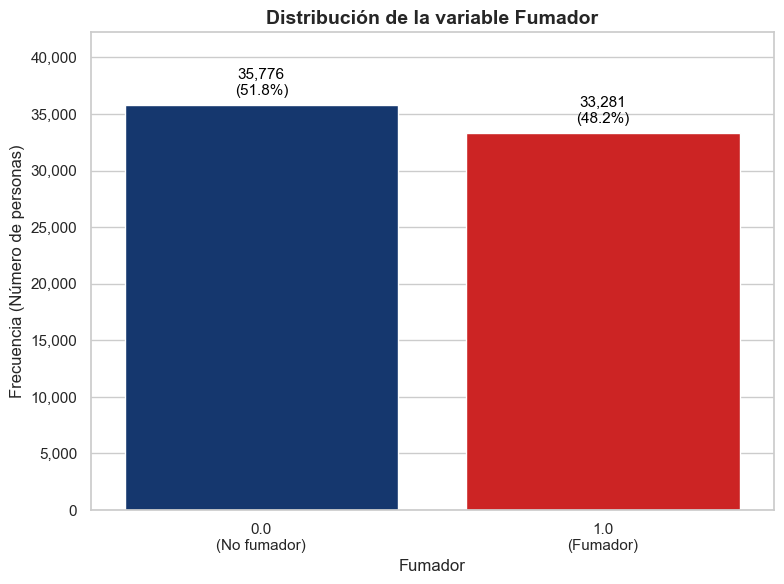

In [19]:
graficar_barras_binarias(
    tabla_fumador, 'Fumador',
    titulo='Distribución de la variable Fumador',
    etiquetas=['0.0\n(No fumador)', '1.0\n(Fumador)'],
    xlabel='Fumador', ylabel='Frecuencia (Número de personas)'
)

Como podemos observar en la tabla, la muestra está bastante equilibrada en cuanto al tabaquismo. El 52.5% de las personas reportan no ser fumadores (según la definición de la encuesta de menos de 100 cigarrillos en su vida), mientras que un 47.5% sí clasifica como fumador.

(`derrame`): Nos dice si el paciente sufrio de un derrame cerebral o no. 

**Tabla**

In [20]:
tabla_derrame = (
    df['derrame']
    .value_counts()
    .reset_index()
    .rename(columns={'derrame': 'derrame', 'count': 'Frecuencia'})
)
tabla_derrame['Porcentaje'] = (tabla_derrame['Frecuencia'] / tabla_derrame['Frecuencia'].sum() * 100).round(1)

print(tabla_derrame)

   derrame  Frecuencia  Porcentaje
0      0.0       64662        93.6
1      1.0        4395         6.4


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


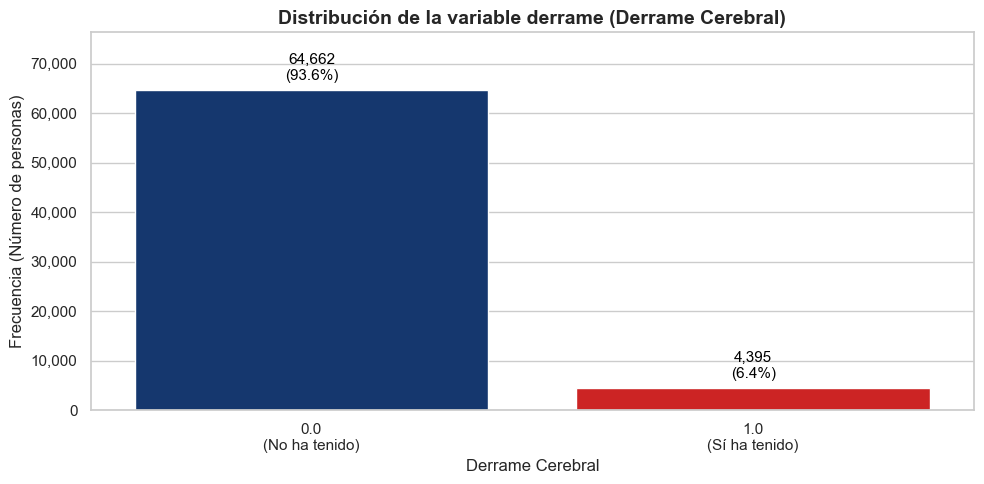

In [21]:
graficar_barras_binarias(
    tabla_derrame, 'derrame',
    titulo='Distribución de la variable derrame (Derrame Cerebral)',
    etiquetas=['0.0\n(No ha tenido)', '1.0\n(Sí ha tenido)'],
    xlabel='Derrame Cerebral', ylabel='Frecuencia (Número de personas)',
    figsize=(10, 5)
)

Como podemos ver, la gran mayoría de los pacientes en esta base de datos (93.8%) no han reportado haber sufrido un derrame cerebral, mientras que una pequeña minoría (6.2%) sí lo ha padecido.

(`EnfCardi`)EnfCardi: Dice si el paciente padece de una enfermedad cardiaca o no. 

**Tabla**

In [22]:
tabla_enfcardi = (
    df['EnfCardi']
    .value_counts()
    .reset_index()
    .rename(columns={'EnfCardi': 'EnfCardi', 'count': 'Frecuencia'})
)
tabla_enfcardi['Porcentaje'] = (tabla_enfcardi['Frecuencia'] / tabla_enfcardi['Frecuencia'].sum() * 100).round(1)

print(tabla_enfcardi)


   EnfCardi  Frecuencia  Porcentaje
0       0.0       58638        84.9
1       1.0       10419        15.1


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


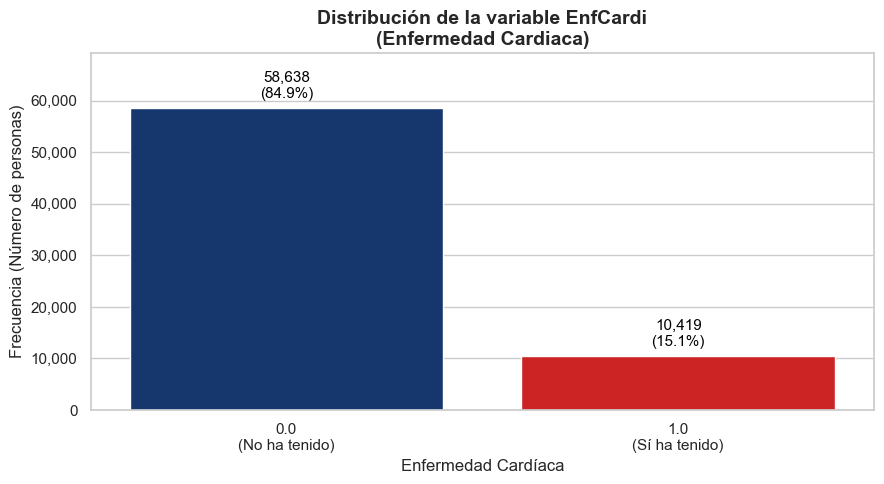

In [23]:
graficar_barras_binarias(
    tabla_enfcardi, 'EnfCardi',
    titulo='Distribución de la variable EnfCardi\n(Enfermedad Cardiaca)',
    etiquetas=['0.0\n(No ha tenido)', '1.0\n(Sí ha tenido)'],
    xlabel='Enfermedad Cardíaca', ylabel='Frecuencia (Número de personas)',
    figsize=(9, 5)
)

El 85.2% de las personas en esta base de datos no tiene un historial de enfermedades coronarias o ataques al corazón, mientras que el 14.8% sí reporta esta condición.

(`ActFisi`): Nos dice si el paciente ha realizado actividad fisica en los ultimops 30 dias.

**Tabla**

In [24]:
tabla_act = (
    df['ActFisi']
    .value_counts()
    .reset_index()
    .rename(columns={'ActFisi': 'ActFisi', 'count': 'Frecuencia'})
)
tabla_act['Porcentaje'] = (tabla_act['Frecuencia'] / tabla_act['Frecuencia'].sum() * 100).round(1)

print(tabla_act)

   ActFisi  Frecuencia  Porcentaje
0      1.0       48097        69.6
1      0.0       20960        30.4


**Grafica**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


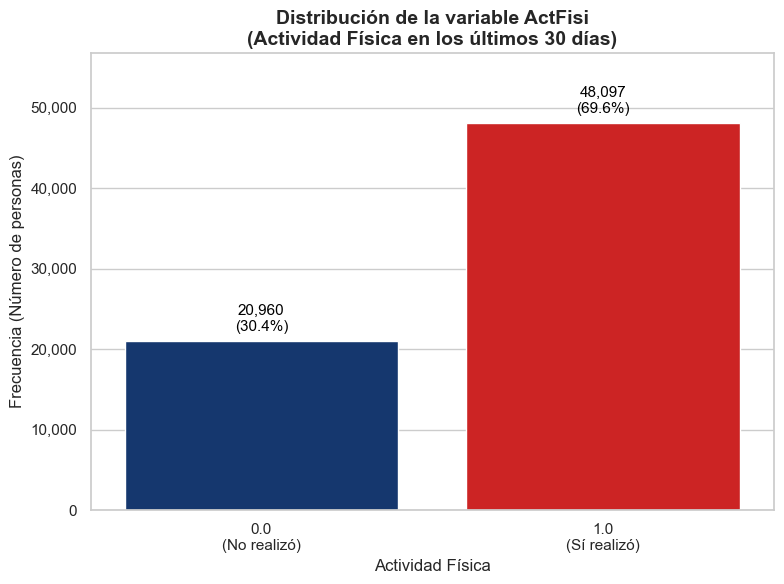

In [25]:
graficar_barras_binarias(
    tabla_act, 'ActFisi',
    titulo='Distribución de la variable ActFisi\n(Actividad Física en los últimos 30 días)',
    etiquetas=['0.0\n(No realizó)', '1.0\n(Sí realizó)'],
    xlabel='Actividad Física', ylabel='Frecuencia (Número de personas)'
)

El 70.3% de las personas encuestadas reporta haber realizado actividad física recientemente, frente a un 29.7% que indica sedentarismo en ese periodo.

(`fruta`): Nos indica si el paciente consume frutas al manos 1 vez al dia.

**Tabla**

In [26]:
tabla_fruta = (
    df['fruta']
    .value_counts()
    .reset_index()
    .rename(columns={'fruta': 'fruta', 'count': 'Frecuencia'})
)
tabla_fruta['Porcentaje'] = (tabla_fruta['Frecuencia'] / tabla_fruta['Frecuencia'].sum() * 100).round(1)

print(tabla_fruta)

   fruta  Frecuencia  Porcentaje
0    1.0       41825        60.6
1    0.0       27232        39.4


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


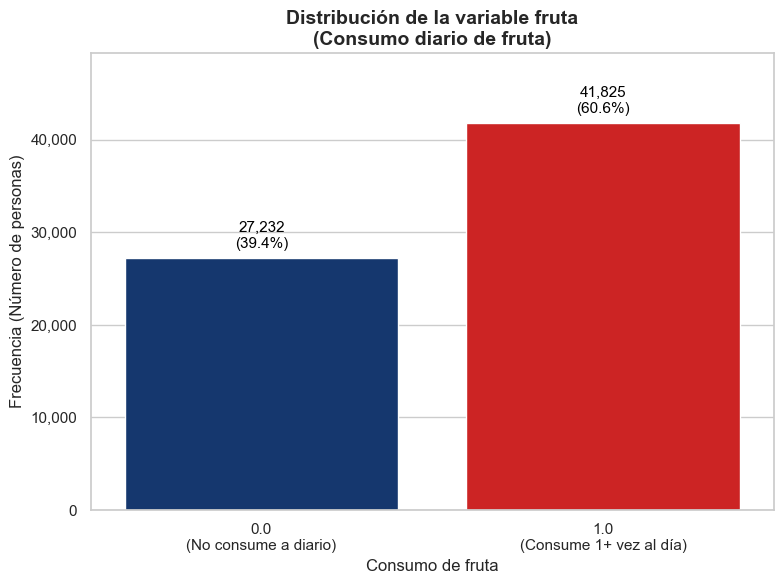

In [27]:
graficar_barras_binarias(
    tabla_fruta, 'fruta',
    titulo='Distribución de la variable fruta\n(Consumo diario de fruta)',
    etiquetas=['0.0\n(No consume a diario)', '1.0\n(Consume 1+ vez al día)'],
    xlabel='Consumo de fruta', ylabel='Frecuencia (Número de personas)'
)

El 61.2% de las personas encuestadas reporta consumir fruta al menos una vez al día, mientras que el 38.8% restante no cumple con este hábito diario.

(`vegetales`): Indica si el paciente consume vegetales diariamente. 

**Tabla** 

In [28]:
tabla_vegetales = (
    df['vegetales']
    .value_counts()
    .reset_index()
    .rename(columns={'vegetales': 'vegetales', 'count': 'Frecuencia'})
)
tabla_vegetales['Porcentaje'] = (tabla_vegetales['Frecuencia'] / tabla_vegetales['Frecuencia'].sum() * 100).round(1)

print(tabla_vegetales)

   vegetales  Frecuencia  Porcentaje
0        1.0       54149        78.4
1        0.0       14908        21.6


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


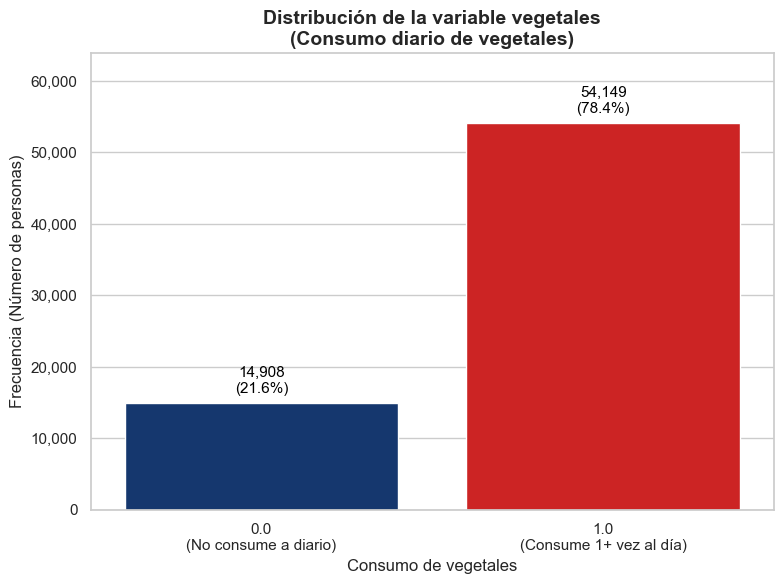

In [29]:
graficar_barras_binarias(
    tabla_vegetales, 'vegetales',
    titulo='Distribución de la variable vegetales\n(Consumo diario de vegetales)',
    etiquetas=['0.0\n(No consume a diario)', '1.0\n(Consume 1+ vez al día)'],
    xlabel='Consumo de vegetales', ylabel='Frecuencia (Número de personas)'
)

El 78.9% de las personas en la muestra reporta consumir vegetales al menos una vez al día, mientras que el 21.1% no lo hace diariamente.

(`Alcohlico`): Nos dice si el paciente es un consumidor freceunte de alcohol

**Tabla**

In [30]:
tabla_alcohol = (
    df['Alcohlico']
    .value_counts()
    .reset_index()
    .rename(columns={'Alcohlico': 'Alcohlico', 'count': 'Frecuencia'})
)
tabla_alcohol['Porcentaje'] = (tabla_alcohol['Frecuencia'] / tabla_alcohol['Frecuencia'].sum() * 100).round(1)

print(tabla_alcohol)

   Alcohlico  Frecuencia  Porcentaje
0        0.0       66052        95.6
1        1.0        3005         4.4


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


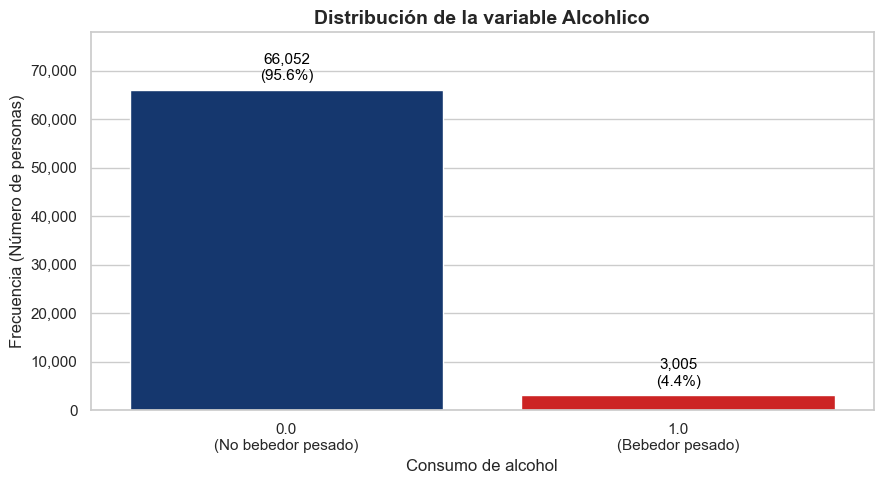

In [31]:
graficar_barras_binarias(
    tabla_alcohol, 'Alcohlico',
    titulo='Distribución de la variable Alcohlico',
    etiquetas=['0.0\n(No bebedor pesado)', '1.0\n(Bebedor pesado)'],
    xlabel='Consumo de alcohol', ylabel='Frecuencia (Número de personas)',
    figsize=(9, 5)
)

Como se puede observar en los datos, una inmensa mayoría de la muestra (95.7%) no entra en la categoría de consumo excesivo de alcohol, mientras que solo un 4.3% clasifica como bebedor pesado según los criterios de la encuesta.

(`eps`): Nos indica si el paciente cuenta con algún tipo de cobertura médica o seguro de salud

**Tabla**
 

In [32]:
tabla_eps = (
    df['eps']
    .value_counts()
    .reset_index()
    .rename(columns={'eps': 'eps', 'count': 'Frecuencia'})
)
tabla_eps['Porcentaje'] = (tabla_eps['Frecuencia'] / tabla_eps['Frecuencia'].sum() * 100).round(1)

print(tabla_eps)

   eps  Frecuencia  Porcentaje
0  1.0       65874        95.4
1  0.0        3183         4.6


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


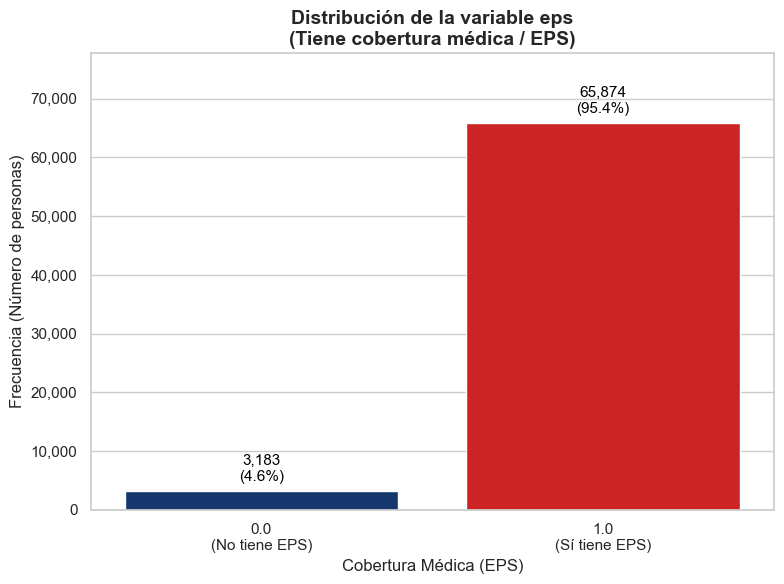

In [33]:
graficar_barras_binarias(
    tabla_eps, 'eps',
    titulo='Distribución de la variable eps\n(Tiene cobertura médica / EPS)',
    etiquetas=['0.0\n(No tiene EPS)', '1.0\n(Sí tiene EPS)'],
    xlabel='Cobertura Médica (EPS)', ylabel='Frecuencia (Número de personas)'
)

Como se puede ver en la tabla, una amplísima mayoría de la población analizada (95.5%) cuenta con cobertura de salud, mientras que solo un 4.5% carece de ella.

(`AfordabilidadMedica`): Nos indica si la persona necesitó ver a un médico en los últimos 12 meses pero no pudo hacerlo debido al costo. 

**Tabla** 

In [34]:
tabla_afordabilidad = (
    df['AfordabilidadMedica']
    .value_counts()
    .reset_index()
    .rename(columns={'AfordabilidadMedica': 'AfordabilidadMedica', 'count': 'Frecuencia'})
)
tabla_afordabilidad['Porcentaje'] = (tabla_afordabilidad['Frecuencia'] / tabla_afordabilidad['Frecuencia'].sum() * 100).round(1)

print(tabla_afordabilidad)

   AfordabilidadMedica  Frecuencia  Porcentaje
0                  0.0       62418        90.4
1                  1.0        6639         9.6


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


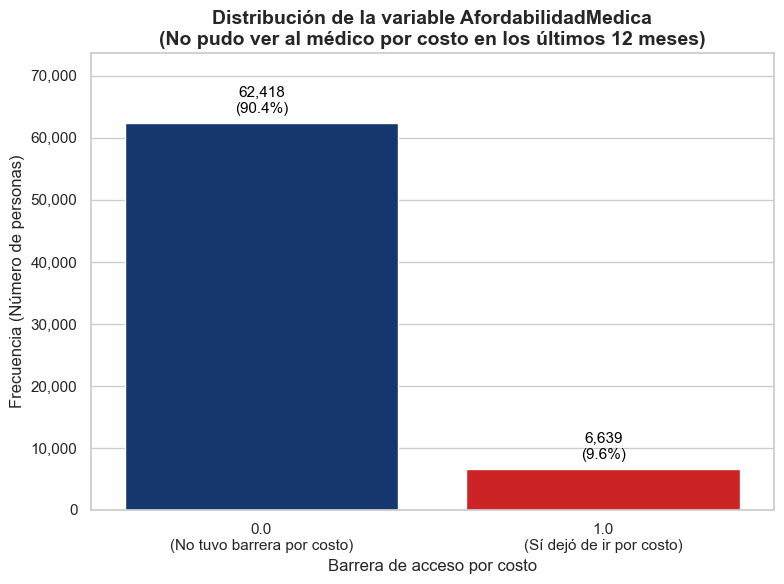

In [35]:
graficar_barras_binarias(
    tabla_afordabilidad, 'AfordabilidadMedica',
    titulo='Distribución de la variable AfordabilidadMedica\n(No pudo ver al médico por costo en los últimos 12 meses)',
    etiquetas=['0.0\n(No tuvo barrera por costo)', '1.0\n(Sí dejó de ir por costo)'],
    xlabel='Barrera de acceso por costo', ylabel='Frecuencia (Número de personas)'
)

Como se observa en los datos, la gran mayoría de los encuestados (90.6%) no experimentó limitaciones económicas para recibir atención médica, mientras que un 9.4% sí se vio en la situación de no poder asistir a una consulta médica por motivos financieros.

(`SaludG`): Responde a la pregunta ¿Diría que en general su salud es..." en una escala del 1 al 5. Siendo 1 exelente, 2 muy buena, 3 buena, 4 regular y 5 pobre. 


**Tabla**

In [36]:
tabla_saludg = (
    df['SaludG']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'SaludG': 'SaludG', 'count': 'Frecuencia'})
)
tabla_saludg['Porcentaje'] = (tabla_saludg['Frecuencia'] / tabla_saludg['Frecuencia'].sum() * 100).round(1)

print(tabla_saludg)

   SaludG  Frecuencia  Porcentaje
0     1.0        7607        11.0
1     2.0       19105        27.7
2     3.0       23246        33.7
3     4.0       13292        19.2
4     5.0        5807         8.4


**Grafica** 

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


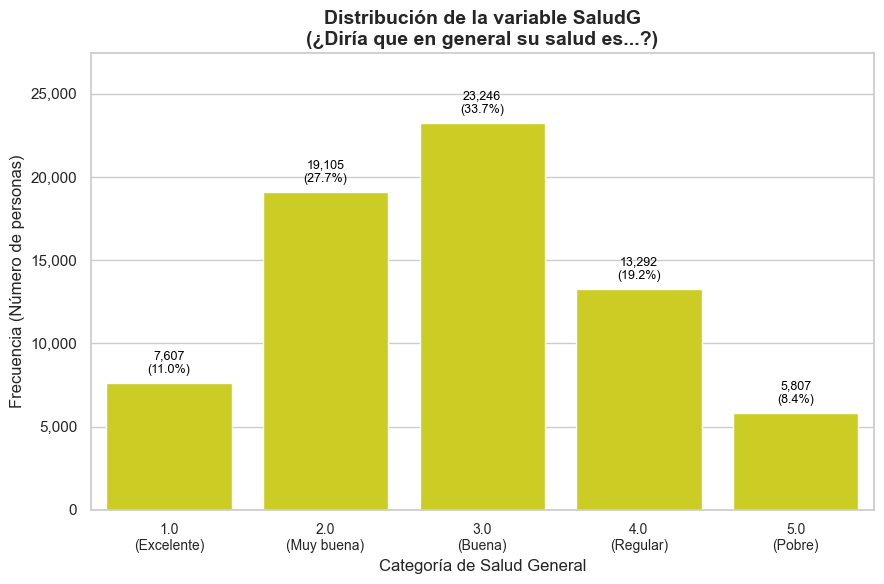

In [37]:
etiquetas_salud = [
    '1.0\n(Excelente)',
    '2.0\n(Muy buena)',
    '3.0\n(Buena)',
    '4.0\n(Regular)',
    '5.0\n(Pobre)'
]

graficar_barras_categoricas(
    tabla_saludg, 'SaludG',
    titulo='Distribución de la variable SaludG\n(¿Diría que en general su salud es...?)',
    xlabel='Categoría de Salud General', ylabel='Frecuencia (Número de personas)',
    etiquetas=etiquetas_salud, figsize=(9, 6)
)

Como se observa en los datos, la mayor concentración de respuestas se encuentra en las categorías de "Buena" (33.1%) y "Muy buena" (28.1%), abarcando más de la mitad de la población analizada, despues le sigue "regular" (19.2%) y por ultimo "exelente" (11%) y "pobre" (8.4%). 

(`DificultadCaminar`): Datos respondiendo a la pregunta de si la persona tiene seria dificultad para caminar o subir escaleras

**Tabla**

In [38]:
tabla_diffwalk = (
    df['DificultadCaminar']
    .value_counts()
    .reset_index()
    .rename(columns={'DificultadCaminar': 'DificultadCaminar', 'count': 'Frecuencia'})
)
tabla_diffwalk['Porcentaje'] = (tabla_diffwalk['Frecuencia'] / tabla_diffwalk['Frecuencia'].sum() * 100).round(1)

print(tabla_diffwalk)

   DificultadCaminar  Frecuencia  Porcentaje
0                0.0       51198        74.1
1                1.0       17859        25.9


**Grafica**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


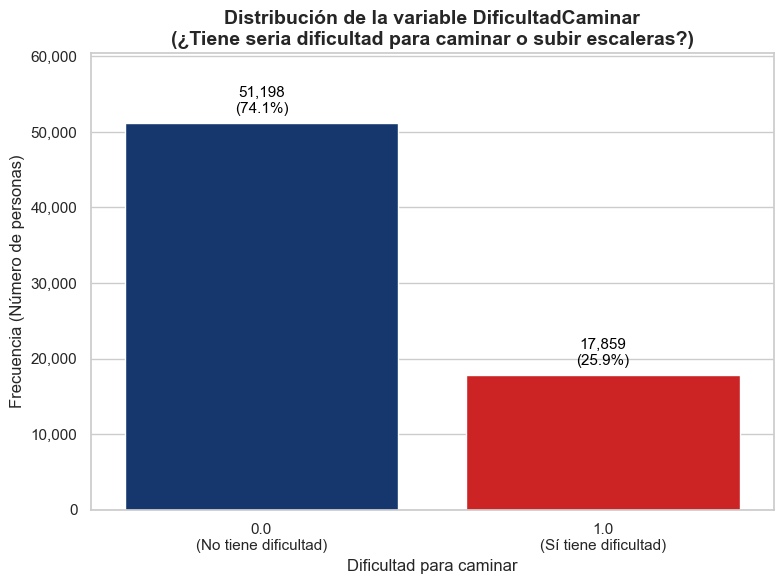

In [39]:
graficar_barras_binarias(
    tabla_diffwalk, 'DificultadCaminar',
    titulo='Distribución de la variable DificultadCaminar\n(¿Tiene seria dificultad para caminar o subir escaleras?)',
    etiquetas=['0.0\n(No tiene dificultad)', '1.0\n(Sí tiene dificultad)'],
    xlabel='Dificultad para caminar', ylabel='Frecuencia (Número de personas)'
)

Como se puede observar en los datos, la gran mayoría de la población encuestada (74.7%) no reporta problemas graves de movilidad, mientras que una cuarta parte de la muestra (25.3%) indica que sí padece dificultades para caminar o subir escaleras.

(`Genero`): Nos hace saber el genero o sexo del paciente: 0 para mujeres y 1 para hombres.

**Tabla**

In [40]:
tabla_genero = (
    df['Genero']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Genero': 'Genero', 'count': 'Frecuencia'})
)
tabla_genero['Porcentaje'] = (tabla_genero['Frecuencia'] / tabla_genero['Frecuencia'].sum() * 100).round(1)

print(tabla_genero)

   Genero  Frecuencia  Porcentaje
0     0.0       37535        54.4
1     1.0       31522        45.6


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


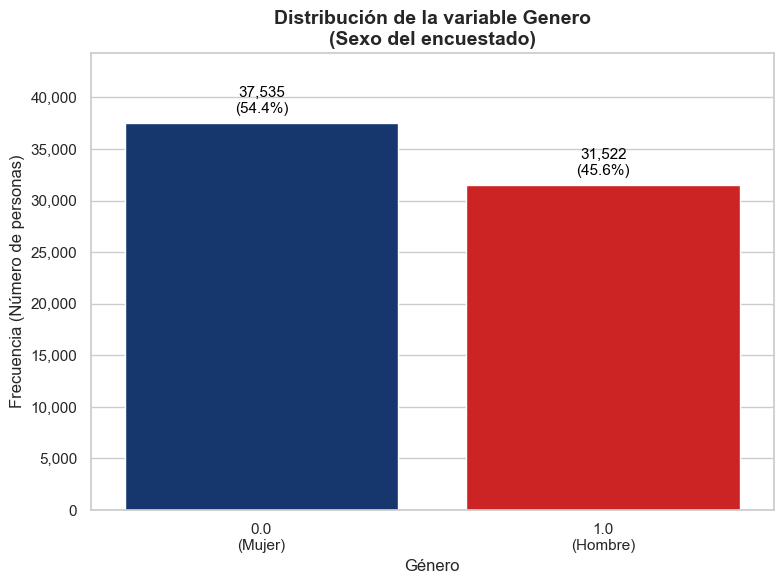

In [41]:
graficar_barras_binarias(
    tabla_genero, 'Genero',
    titulo='Distribución de la variable Genero\n(Sexo del encuestado)',
    etiquetas=['0.0\n(Mujer)', '1.0\n(Hombre)'],
    xlabel='Género', ylabel='Frecuencia (Número de personas)'
)

Como se puede ver en los datos, la muestra cuenta con una mayor proporción de mujeres (54.3%) frente a los hombres (45.7%), manteniéndose sin embargo en un rango bastante equilibrado.

(`Edad`): Está codificada en una escala ordinal de 13 categorías de rangos de edad de 5 años (desde 1 para 18-24 hasta 13 para mayores de 80 años).

**Tabla**

In [42]:
tabla_edad = (
    df['Edad']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Edad': 'Edad', 'count': 'Frecuencia'})
)
tabla_edad['Porcentaje'] = (tabla_edad['Frecuencia'] / tabla_edad['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Edad:")
print(tabla_edad)

Tabla de Frecuencias de Edad:
    Edad  Frecuencia  Porcentaje
0    1.0         972         1.4
1    2.0        1378         2.0
2    3.0        1994         2.9
3    4.0        2691         3.9
4    5.0        3387         4.9
5    6.0        4472         6.5
6    7.0        6627         9.6
7    8.0        8392        12.2
8    9.0        9873        14.3
9   10.0       10585        15.3
10  11.0        7932        11.5
11  12.0        5358         7.8
12  13.0        5396         7.8


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


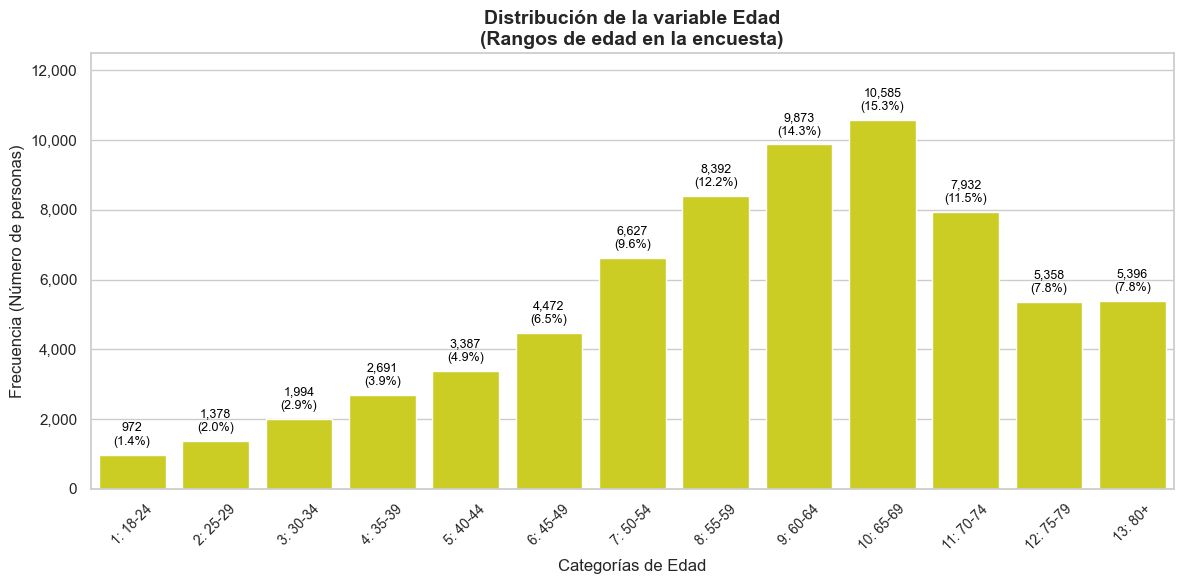

In [43]:
etiquetas_edad = [
    '1: 18-24', '2: 25-29', '3: 30-34', '4: 35-39',
    '5: 40-44', '6: 45-49', '7: 50-54', '8: 55-59',
    '9: 60-64', '10: 65-69', '11: 70-74', '12: 75-79', '13: 80+'
]

graficar_barras_categoricas(
    tabla_edad, 'Edad',
    titulo='Distribución de la variable Edad\n(Rangos de edad en la encuesta)',
    xlabel='Categorías de Edad', ylabel='Frecuencia (Número de personas)',
    etiquetas=etiquetas_edad, figsize=(12, 6), rotation=45
)

La distribución etaria tiende a sesgarse hacia los adultos de mediana edad y adultos mayores (categorías del 7 al 13, es decir, de 50 años en adelante).

(`Educacion`): está codificada en una escala ordinal de 6 niveles que miden el nivel educativo máximo alcanzado por el encuestado.

**Tabla**

In [44]:
tabla_educacion = (
    df['Educacion']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Educacion': 'Educacion', 'count': 'Frecuencia'})
)
tabla_educacion['Porcentaje'] = (tabla_educacion['Frecuencia'] / tabla_educacion['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Educación:")
print(tabla_educacion)

Tabla de Frecuencias de Educación:
   Educacion  Frecuencia  Porcentaje
0        1.0          75         0.1
1        2.0        1647         2.4
2        3.0        3447         5.0
3        4.0       19397        28.1
4        5.0       19845        28.7
5        6.0       24646        35.7


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


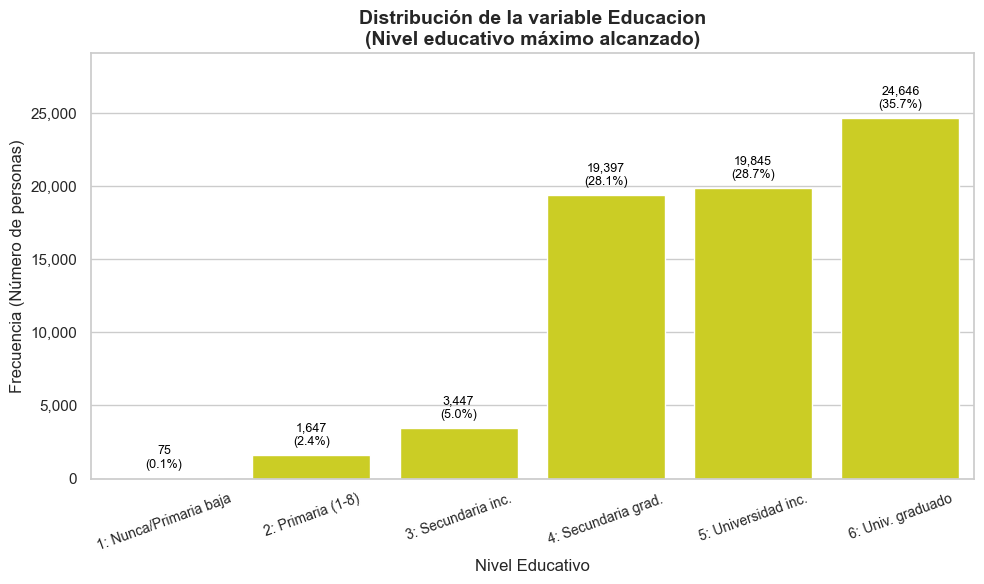

In [45]:
etiquetas_educacion = [
    '1: Nunca/Primaria baja',
    '2: Primaria (1-8)',
    '3: Secundaria inc.',
    '4: Secundaria grad.',
    '5: Universidad inc.',
    '6: Univ. graduado'
]

graficar_barras_categoricas(
    tabla_educacion, 'Educacion',
    titulo='Distribución de la variable Educacion\n(Nivel educativo máximo alcanzado)',
    xlabel='Nivel Educativo', ylabel='Frecuencia (Número de personas)',
    etiquetas=etiquetas_educacion, figsize=(10, 6), rotation=20
)

La mayoria de personas encuestadas completaron al menos la secundaria mientras que unos pocos tienen un nivel educativo inferior a secundaria. 

(`Ingresos`): Esta variable está codificada en una escala ordinal de 8 niveles basados en los ingresos familiares totales anuales (antes de impuestos).

**Tabla**

In [46]:
tabla_ingresos = (
    df['Ingresos']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'Ingresos': 'Ingresos', 'count': 'Frecuencia'})
)
tabla_ingresos['Porcentaje'] = (tabla_ingresos['Frecuencia'] / tabla_ingresos['Frecuencia'].sum() * 100).round(1)

print("Tabla de Frecuencias de Ingresos:")
print(tabla_ingresos)

Tabla de Frecuencias de Ingresos:
   Ingresos  Frecuencia  Porcentaje
0       1.0        3611         5.2
1       2.0        4497         6.5
2       3.0        5552         8.0
3       4.0        6646         9.6
4       5.0        7975        11.5
5       6.0       10195        14.8
6       7.0       11274        16.3
7       8.0       19307        28.0


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


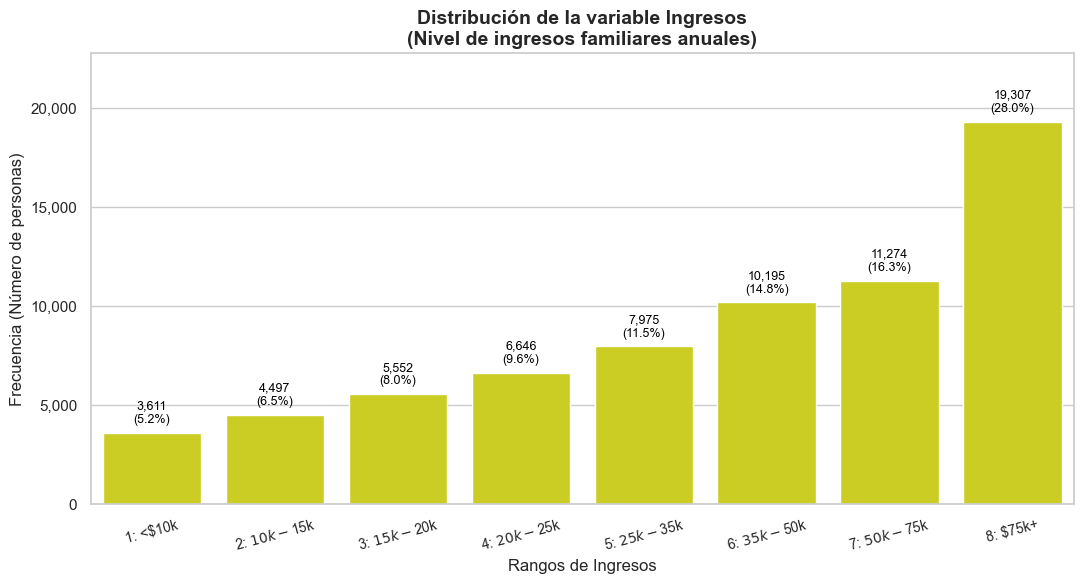

In [47]:
etiquetas_ingresos = [
    '1: <$10k',
    '2: $10k-$15k',
    '3: $15k-$20k',
    '4: $20k-$25k',
    '5: $25k-$35k',
    '6: $35k-$50k',
    '7: $50k-$75k',
    '8: $75k+'
]

graficar_barras_categoricas(
    tabla_ingresos, 'Ingresos',
    titulo='Distribución de la variable Ingresos\n(Nivel de ingresos familiares anuales)',
    xlabel='Rangos de Ingresos', ylabel='Frecuencia (Número de personas)',
    etiquetas=etiquetas_ingresos, figsize=(11, 6), rotation=15
)

Podemos ver que la mayoria de personas encuestadas cuentan con ingresos anuales superiores a 25k\$, gran parte de los encuestados ganando mas de 75k\$. Por otro lado hay menos personas ganando por debajo de los 25k\$, siendo muy poco el porcentaje de gente que gana menos de 10k\$. 

## 7. Variables Numéricas

(`IMC`): esta variable indica el indice de masa corporal del paciente. 

**Tabla**

In [48]:

promedio = df['IMC'].mean()
minimo = df['IMC'].min()
maximo = df['IMC'].max()

q1 = df['IMC'].quantile(0.25)
q3 = df['IMC'].quantile(0.75)
rango_intercuartil = q3 - q1

tabla_imc = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), rango_intercuartil, minimo, maximo]
})

print(tabla_imc)

                Estadística  Valor
0                  Promedio  29.96
1  Rango Intercuartil (IQR)   8.00
2                    Mínimo  12.00
3                    Máximo  98.00


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


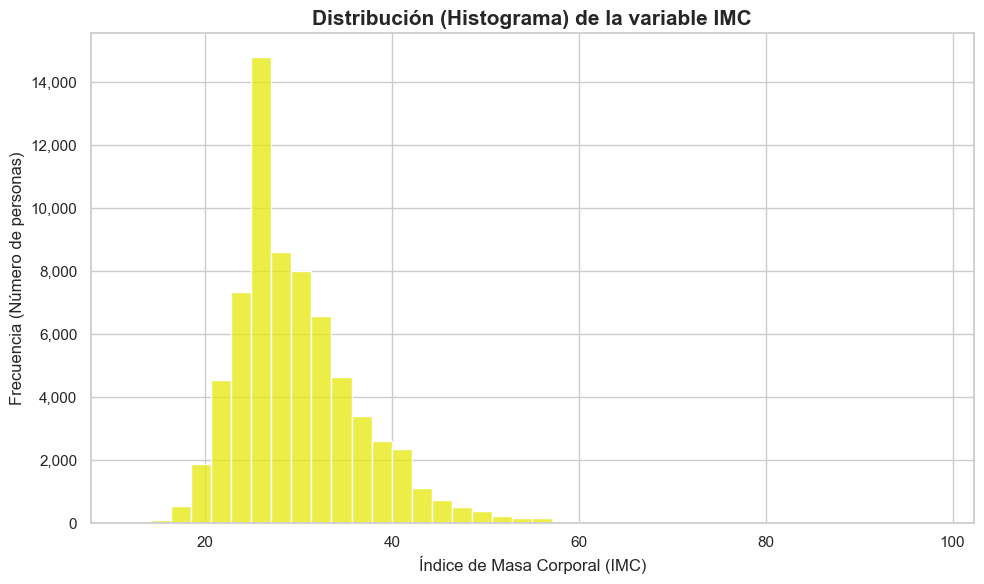

In [49]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df, x='IMC', bins=40, color=COLOR_UNICO)

plt.title('Distribución (Histograma) de la variable IMC', fontsize=15, fontweight='bold')
plt.xlabel('Índice de Masa Corporal (IMC)', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
formatear_miles(ax, 'y')

plt.tight_layout()
plt.show()

 Como podemos ver, la distribución no es una campana simétrica perfecta. Tiene una "cola" larga que se extiende hacia la derecha. Esto se debe a los valores atípicos (outliers) de IMC muy altos (personas con obesidad severa, llegando hasta 98.0) que vimos en el diagrama de caja anterior.
 La gran mayoría de las personas se concentran en el rango de un IMC entre 25.0 y 30.0, lo cual coincide con el rango de sobrepeso según las categorías médicas estándar. El punto más alto del histograma ocurre justo en este rango.

(`SaludM`): Mide el número de días (de 0 a 30) en los que la salud mental de la persona no fue buena durante los últimos 30 días.

**Tabla**

In [50]:
promedio = df['SaludM'].mean()
minimo = df['SaludM'].min()
maximo = df['SaludM'].max()
q1 = df['SaludM'].quantile(0.25)
q3 = df['SaludM'].quantile(0.75)
iqr = q3 - q1

tabla_stats_saludm = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), f"{iqr} (Q1: {q1}, Q3: {q3})", minimo, maximo]
})
print(tabla_stats_saludm)

                Estadística                   Valor
0                  Promedio                    3.84
1  Rango Intercuartil (IQR)  3.0 (Q1: 0.0, Q3: 3.0)
2                    Mínimo                     0.0
3                    Máximo                    30.0


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


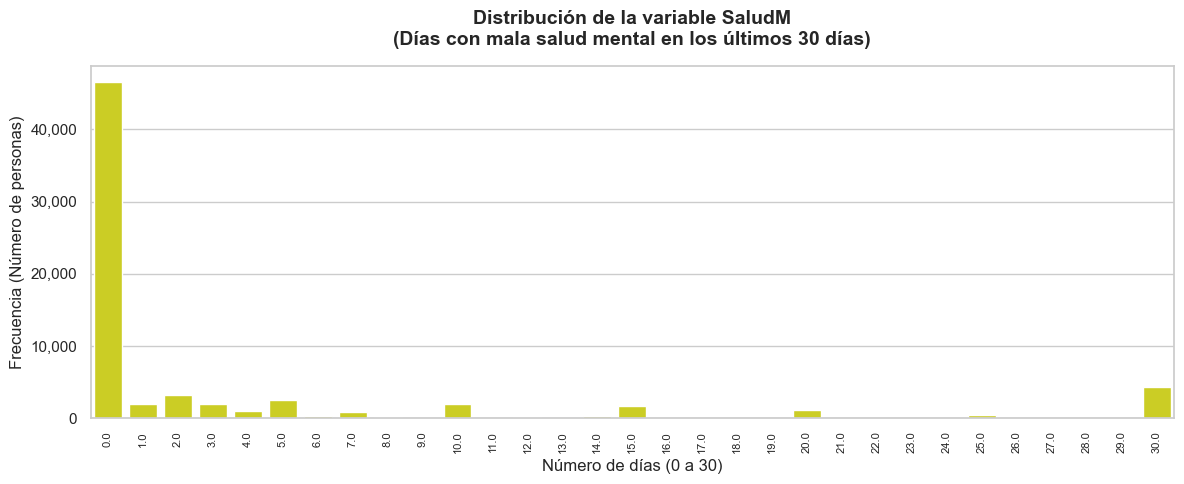

In [51]:
tabla_saludm_dias = (
    df['SaludM']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'count': 'Frecuencia'})
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=tabla_saludm_dias, x='SaludM', y='Frecuencia', color=COLOR_UNICO)
formatear_miles(ax, 'y')

plt.title('Distribución de la variable SaludM\n(Días con mala salud mental en los últimos 30 días)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de días (0 a 30)', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

Como se ve en el IQR, el 75% de las personas reportan haber tenido 2 días o menos de mala salud mental al mes (y una gran mayoría reporta exactamente 0 días). Sin embargo, existen valores atípicos (outliers) que alcanzan hasta los 30 días completos.

(`SaludF`): Mide el número de días (de 0 a 30) en los que la salud física del encuestado no fue buena durante los últimos 30 días.

**Tabla**

In [52]:
promedio = df['SaludF'].mean()
minimo = df['SaludF'].min()
maximo = df['SaludF'].max()
q1 = df['SaludF'].quantile(0.25)
q3 = df['SaludF'].quantile(0.75)
iqr = q3 - q1

tabla_stats_saludf = pd.DataFrame({
    'Estadística': ['Promedio', 'Rango Intercuartil (IQR)', 'Mínimo', 'Máximo'],
    'Valor': [round(promedio, 2), f"{iqr} (Q1: {q1}, Q3: {q3})", minimo, maximo]
})
print(tabla_stats_saludf)

                Estadística                   Valor
0                  Promedio                    5.95
1  Rango Intercuartil (IQR)  6.0 (Q1: 0.0, Q3: 6.0)
2                    Mínimo                     0.0
3                    Máximo                    30.0


**Grafico**

c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\angel\miniconda3\envs\dataviz202630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


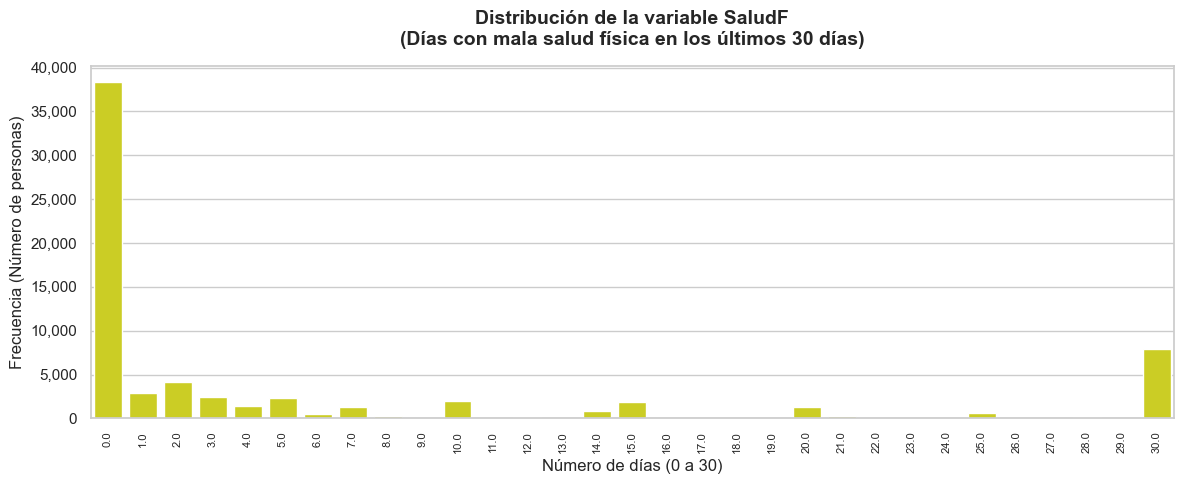

In [53]:
tabla_saludf_dias = (
    df['SaludF']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'count': 'Frecuencia'})
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=tabla_saludf_dias, x='SaludF', y='Frecuencia', color=COLOR_UNICO)
formatear_miles(ax, 'y')

plt.title('Distribución de la variable SaludF\n(Días con mala salud física en los últimos 30 días)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de días (0 a 30)', fontsize=12)
plt.ylabel('Frecuencia (Número de personas)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

El promedio de días con mala salud física es ligeramente mayor (5.81 días frente a 3.75). El rango intercuartil indica que el 75% central de las personas reportan tener 6 días o menos de malestar físico al mes, aunque encontramos valores extremos que llegan hasta los 30 días completos.